# Exploratory Data Analysis (EDA)
## Gas Sensor Array Drift Dataset

This notebook performs exploratory data analysis on the processed gas sensor dataset used for building machine learning models in the IoT-based gas monitoring system.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/processed/processed_gas_sensor.csv")

df.head()


,label,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_118,sensor_119,sensor_120,sensor_121,sensor_122,sensor_123,sensor_124,sensor_125,sensor_126,sensor_127
0,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [3]:
print("Dataset Shape:", df.shape)


Dataset Shape: (13910, 129)


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 129 entries, label to sensor_127
dtypes: float64(128), int64(1)
memory usage: 13.7 MB


In [5]:
df.isnull().sum().sum()


np.int64(0)

In [6]:
df.describe()


,label,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_118,sensor_119,sensor_120,sensor_121,sensor_122,sensor_123,sensor_124,sensor_125,sensor_126,sensor_127
count,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,...,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000
mean,3.387994,50435.066174,6.638156,12.936688,18.743953,26.890695,-9.158655,-14.402383,-59.927598,57340.104585,...,-9.601927,-19.136500,19688.565373,6.072066,7.138634,14.929364,19.090980,-4.901016,-8.167792,-16.089791
std,1.728602,69844.785952,13.486391,17.610061,24.899450,38.107685,12.729206,21.304606,131.017675,64045.265134,...,9.220031,26.516679,14281.652395,4.642192,5.248573,12.437311,14.391810,4.195360,7.637701,20.958479
min,1.000000,-16757.598600,0.088287,0.000100,0.000100,0.000100,-131.332873,-227.627758,-1664.735576,-16119.460900,...,-76.069200,-482.278033,-8297.548800,0.712112,0.003238,0.011488,0.118849,-30.205911,-58.844076,-410.152297
25%,2.000000,6694.725950,2.284843,1.633350,2.386836,4.967988,-11.587169,-17.292559,-48.492764,13287.301875,...,-13.212575,-22.363498,8837.838750,3.007381,3.059178,5.407551,8.039227,-6.789599,-11.162406,-18.938690
50%,3.000000,19364.439350,3.871227,4.977123,7.250892,11.680725,-3.338700,-4.956917,-14.040088,37764.263200,...,-7.338850,-13.527887,16313.967300,4.973783,5.809107,11.325214,14.560676,-3.881763,-6.305962,-11.747499
75%,5.000000,63104.837125,8.400619,17.189166,26.411109,34.843226,-1.126897,-1.670327,-5.212213,70300.782575,...,-3.260080,-7.358031,27009.592425,7.389566,10.222169,21.207572,26.547437,-1.804032,-2.874532,-6.429690
max,6.000000,670687.347700,1339.879283,167.079751,226.619457,993.605306,-0.006941,22.201589,115.273147,502202.812500,...,9.270956,11.516418,96706.792700,45.574835,32.203601,297.225880,195.242555,-0.003817,6.851792,8.357968


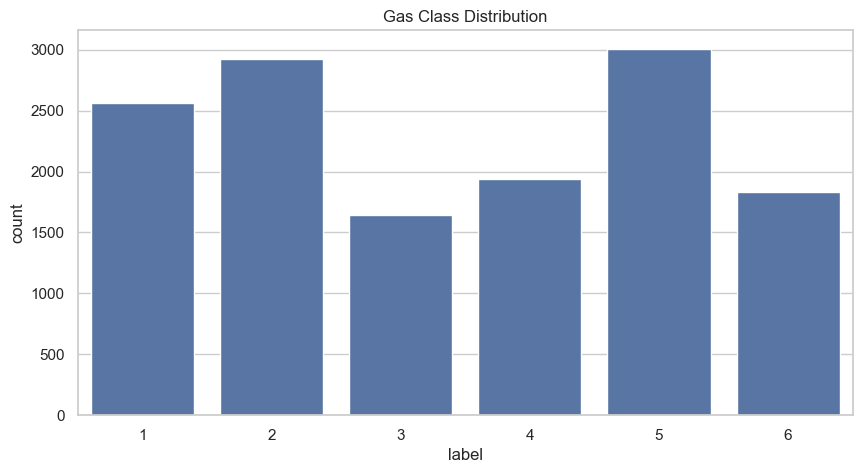

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['label'])
plt.title("Gas Class Distribution")
plt.show()


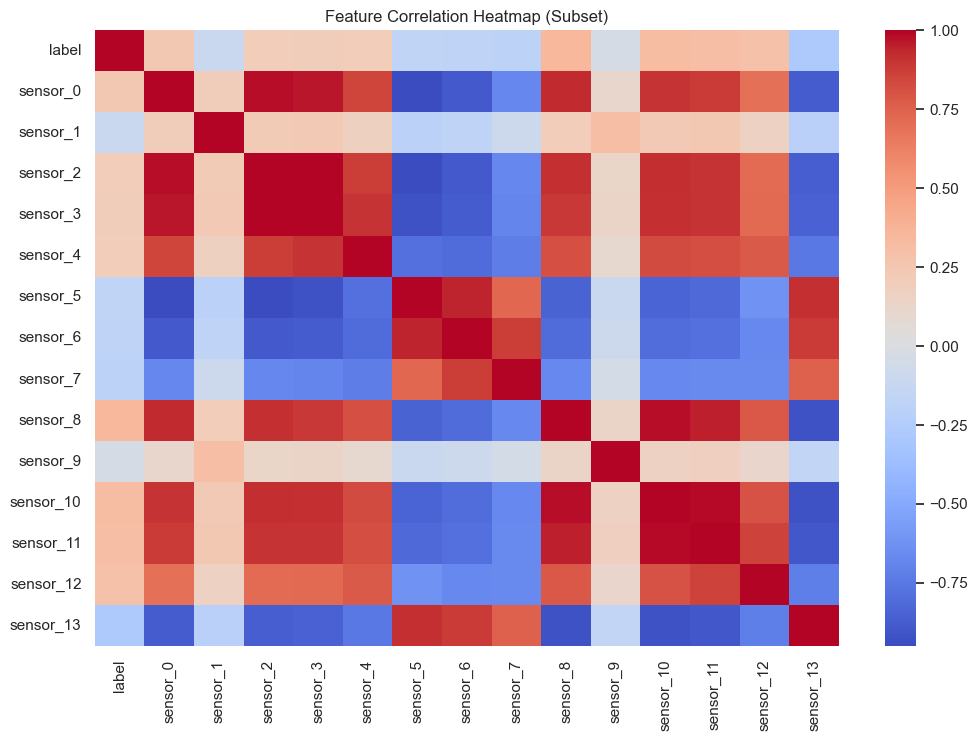

In [8]:
subset = df.iloc[:, :15]  # label + first sensors

plt.figure(figsize=(12,8))
sns.heatmap(subset.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Subset)")
plt.show()


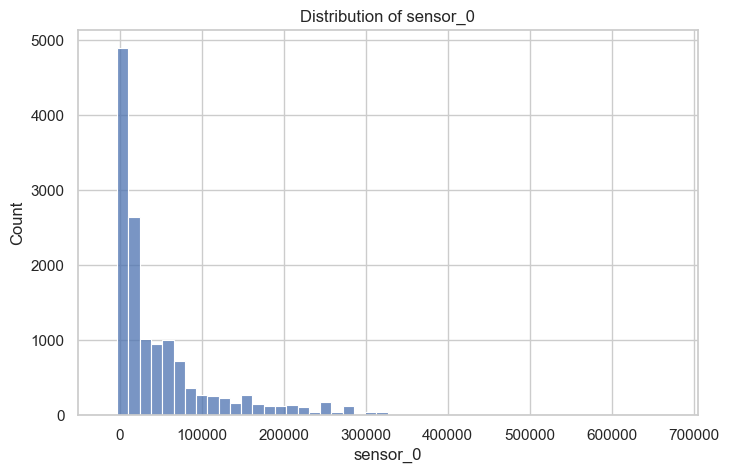

In [9]:
sensor_col = df.columns[1]

plt.figure(figsize=(8,5))
sns.histplot(df[sensor_col], bins=50)
plt.title(f"Distribution of {sensor_col}")
plt.show()


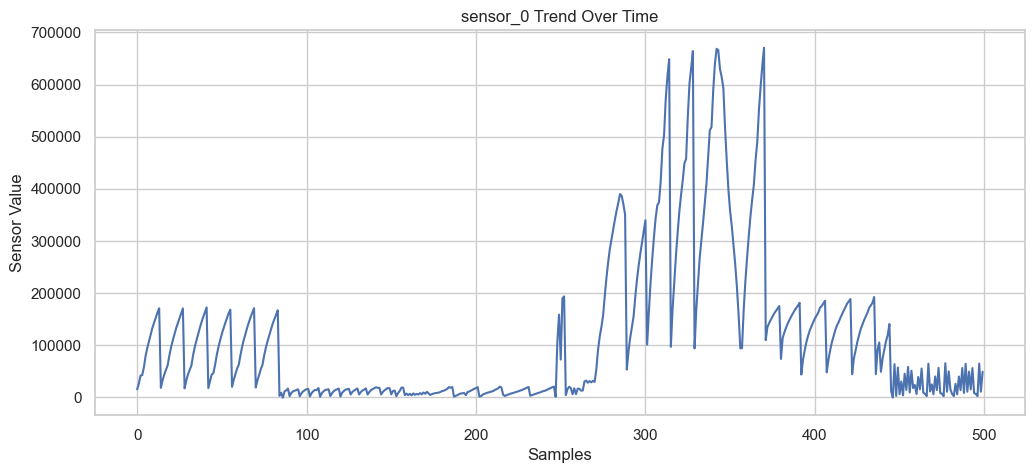

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df[sensor_col].iloc[:500])
plt.title(f"{sensor_col} Trend Over Time")
plt.xlabel("Samples")
plt.ylabel("Sensor Value")
plt.show()


## Key Observations

- The dataset contains multivariate sensor readings used to detect different gases.
- No major missing data was observed after preprocessing.
- Sensor distributions indicate measurable variation across samples.
- Class distribution confirms multiple gas categories for classification.
- Sensor trends demonstrate sequential behavior, supporting time-series modeling.

This exploratory analysis confirms that the dataset is suitable for both classification and forecasting tasks within an IoT analytics framework.
